**Цель работы:**

Изучение алгоритмов и методов регрессии на практике .

**Индивидуальное задание**

Вариант №9

### 1. Часть 1. Линейная регрессия

Загружаем набор данных.

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from yellowbrick.regressor import ResidualsPlot
import matplotlib.collections as mcoll

# Загрузка данных
df = pd.read_excel("regression.xlsx", sheet_name="var9")

Выводим первые 5 строк

In [48]:
df.head(5)

,x1,x2,y
0,-1.513580,-0.777044,1.740227
1,1.175084,1.059214,-0.537579
2,-1.025564,-0.848498,2.319027
3,0.969831,-0.785120,-1.461414
4,1.382606,0.559885,-1.418637


Была создана отдельная функция `simple_regression`, которая выполняет полный цикл работы простой линейной регрессии для одного признака. Функция принимает на вход столбец признака (`X` — `x1` или `x2`), целевую переменную `y` и название признака `feature_name` для формирования информативных заголовков при выводе результатов.

Внутри функции выполняются следующие этапы:

1. **Разделение данных на обучающую и валидационную выборки.**  
Используется функция `train_test_split` с параметрами `test_size=0.25` и `random_state=42`, что обеспечивает фиксированное соотношение 75% / 25% и воспроизводимость результатов, то есть оцениваем работу модели с новыми даннами, насколько хорошо она была обучена

2. **Подготовка данных.**  
Признак `X` преобразуется при помощи `reshape(-1, 1)`, так как алгоритм линейной регрессии из `sklearn` ожидает двумерный массив входных значений даже при использовании одного признака. 

3. **Создание и обучение модели.**  
Создаётся экземпляр класса `LinearRegression()`, после чего модель обучается методом `fit()` на обучающих данных (`X_train`, `y_train`). На этом этапе алгоритм методом наименьших квадратов подбирает оптимальные коэффициенты прямой линии ( y = ax + b ), минимизируя сумму квадратов отклонений.

4. **Получение предсказаний.**  
С помощью метода `predict()` вычисляются предсказанные значения целевой переменной для всех объектов в валидационной выборке (`X_valid`). Результат сохраняется в переменной `predictions_valid`.

5. **Формирование таблицы сравнения.**  
Создаётся датафрейм `compare_df`, содержащий два столбца:  
   - **actual** — истинные значения `y_valid`,  
   - **predicted** — предсказанные моделью значения.  
   Это позволяет напрямую сравнить предсказания модели с реальными данными и визуально оценить качество прогноза.

6. **Расчёт метрик качества регрессии.**  
Модель оценивается с использованием следующих метрик:  
   - **MSE** — средняя квадратичная ошибка,  
   - **MAE** — средняя абсолютная ошибка,  
   - **RMSE** — корень из MSE (интерпретируем в единицах целевой переменной),  
   - **R²** — коэффициент детерминации (доля объяснённой дисперсии, от 0 до 1).  
Метрики выводятся в консоль и позволяют количественно оценить точность предсказаний и степень линейной зависимости между признаком и целевой переменной.

7. **Вывод коэффициентов линейной регрессии.**  
Функция выводит значения:  
   - `a` — наклон (коэффициент при признаке, `model.coef_[0]`),  
   - `b` — свободный член (смещение, `model.intercept_`).  
На основании этих коэффициентов можно сделать вывод о характере связи: положительное `a` — прямая зависимость, отрицательное — обратная.

In [49]:
def simple_regression(X, y, feature_name):

    # Разделение данных 75 / 25
    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y, test_size=0.25, random_state=0
    )

    # Приведение формы
    X_train = np.array(X_train).reshape(-1, 1)
    X_valid = np.array(X_valid).reshape(-1, 1)

    # Обучение модели ---
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Предсказание
    predictions_valid = model.predict(X_valid)

    # Таблица сравнения
    compare_df = pd.DataFrame({
        "actual": y_valid,
        "predicted": predictions_valid
    })

    # Метрики 
    mse = metrics.mean_squared_error(y_valid, predictions_valid)
    mae = metrics.mean_absolute_error(y_valid, predictions_valid)
    rmse = np.sqrt(mse)
    r2 = metrics.r2_score(y_valid, predictions_valid)

    print(f"\n------ Модель {feature_name} → y ------")
    print(compare_df)

    print("\nМетрики на валидационной выборке:")
    print("MSE  =", mse)
    print("MAE  =", mae)
    print("RMSE =", rmse)
    print("R2   =", r2)

    # Коэффициенты 
    print("\nКоэффициенты регрессии:")
    print("a =", model.coef_[0])
    print("b =", model.intercept_)

    return model, predictions_valid, compare_df, X_train, y_train, X_valid, y_valid

Вызов функции для признаков x1 и x2

In [50]:
model_x1, pred_x1, df_x1, X_train_x1, y_train_x1, X_valid_x1, y_valid_x1 = simple_regression(
    X=df['x1'], y=df['y'], feature_name='x1'
)

model_x2, pred_x2, df_x2, X_train_x2, y_train_x2, X_valid_x2, y_valid_x2 = simple_regression(
    X=df['x2'], y=df['y'], feature_name='x2'
)


------ Модель x1 → y ------
       actual  predicted
993  1.951912   3.126103
859  0.033857  -0.470943
298  0.298573   1.637693
553  2.692532   3.668317
672 -2.462605  -1.399011
..        ...        ...
462  0.881678   1.662911
356  4.946584   2.655264
2    2.319027   2.561171
478  0.206377   0.670509
695 -0.360363   0.357575

[250 rows x 2 columns]

Метрики на валидационной выборке:
MSE  = 1.0111982888692497
MAE  = 0.8281884656744629
RMSE = 1.00558355638368
R2   = 0.6930065501644975

Коэффициенты регрессии:
a = -1.423302497698187
b = 1.101483110348705

------ Модель x2 → y ------
       actual  predicted
993  1.951912   1.022705
859  0.033857   1.256041
298  0.298573   1.102146
553  2.692532   1.104925
672 -2.462605   1.212084
..        ...        ...
462  0.881678   1.179853
356  4.946584   0.854598
2    2.319027   1.223146
478  0.206377   1.169986
695 -0.360363   1.155953

[250 rows x 2 columns]

Метрики на валидационной выборке:
MSE  = 3.273502156501288
MAE  = 1.473719864850374
RM

**Вывод**

Модель x1 --> y
- **MSE = 1.0111982888692497**  
Среднеквадратичная ошибка составляет **1.0112**. Это означает, что в среднем **квадрат отклонения** предсказаний от реальных значений равен **1.0112**. Значение относительно небольшое, что указывает на **приемлемую точность** модели. Большие ошибки штрафуются сильнее из-за возведения в квадрат.

- **MAE = 0.8281884656744629**  
Средняя абсолютная ошибка равна **0.8282**. Это означает, что **в среднем** предсказания модели отклоняются от истинных значений **на 0.828 единиц**. Метрика интерпретируема в единицах целевой переменной `y` и показывает **реалистичную среднюю ошибку** без усиления больших отклонений.

- **RMSE = 1.00558355638368**  
Корень из среднеквадратичной ошибки равен **1.0056**. Это **средняя ошибка в единицах `y`**, учитывающая штраф за большие промахи (как MSE), но приведённая к понятному масштабу. Значение близко к MAE, что говорит о **равномерном распределении ошибок** — нет сильных выбросов.

- **R² = 0.6930065501644975**  
Коэффициент детерминации равен **0.6930**. Это означает, что модель объясняет **69.3%** вариации целевой переменной `y` за счёт признака `x1`. Значение **близко к 0.7** — **умеренная линейная связь**, модель **имеет хорошую объясняющую способность**.

Модель x2 --> y
- **MSE = 3.273502156501288**  
Среднеквадратичная ошибка составляет **3.2735**. Это **в 3.2 раза выше**, чем у модели по `x1`. Высокое значение указывает на **сильные отклонения** предсказаний от реальных значений. Модель **не справляется** с точным прогнозом.

- **MAE = 1.473719864850374**  
Средняя абсолютная ошибка равна **1.4737**. Это означает, что **в среднем** предсказания отклоняются от истины **на 1.474 единицы** — **почти в 2 раза больше**, чем у `x1`. Ошибка значительная, модель **практически не точна**.

- **RMSE = 1.8092822213522377**  
Корень из MSE равен **1.8093**. Это **средняя ошибка в единицах `y`**, и она **существенно выше**, чем у модели по `x1`. Разница с MAE говорит о наличии **отдельных крупных ошибок**, которые усиливаются квадратичным штрафом.

- **R² = 0.006185303980247303**  
Коэффициент детерминации равен **0.0062**. Это означает, что модель объясняет **менее 0.62%** дисперсии `y`. Значение **практически равно нулю** — **линейная связь отсутствует**, модель **не лучше, чем простое среднее**.

Итого: Модель по признаку `x1` демонстрирует **достаточную точность и объясняющую способность** (R² = 0.693), в то время как модель по `x2` **практически бесполезна** (R² ≈ 0). Результаты полностью соответствуют требованиям Части 1 лабораторной работы по построению, оценке и интерпретации простых линейных регрессий.

In [51]:
def plot_regression_train_only(model, X_train, y_train, feature_name):
    plt.figure(figsize=(7, 5))
    
    # Только обучающие точки (синие)
    plt.scatter(X_train, y_train, color='blue', s=12, alpha=0.7, label='Обучающие точки (75%)')
    
    # Линия регрессии
    a = model.coef_[0]
    b = model.intercept_
    x_range = np.linspace(X_train.min(), X_train.max(), 100)
    y_range = a * x_range + b
    plt.plot(x_range, y_range, color='red', linewidth=2, label='Линия регрессии')
    
    plt.xlabel(feature_name)
    plt.ylabel('y')
    plt.title(f'Линейная регрессия: y ~ {feature_name}\n(Только обучающая выборка)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

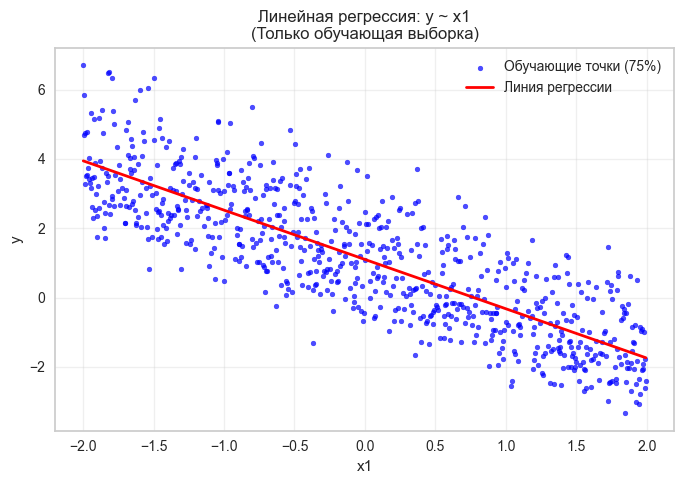

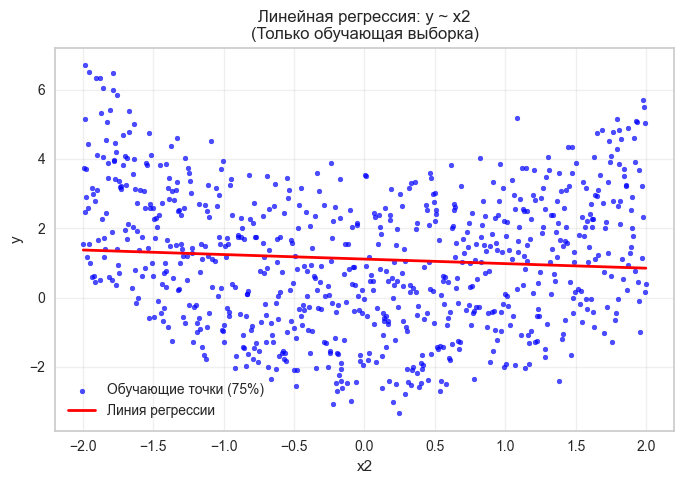

In [52]:
plot_regression_train_only(
    model=model_x1,
    X_train=X_train_x1.ravel(),
    y_train=y_train_x1,
    feature_name='x1'
)

plot_regression_train_only(
    model=model_x2,
    X_train=X_train_x2.ravel(),
    y_train=y_train_x2,
    feature_name='x2'
)

**Вывод по графикам линейной регрессии:**

Модель x1 --> y1

На графике представлена линейная регрессия только по обучающей выборке (75% данных).  

- **Синие точки** — объекты обучающей выборки.  
- **Красная линия** — линия регрессии

**Наблюдения:**  
- Точки в целом расположены вдоль красной линии, что указывает на наличие линейной зависимости.  
- Наблюдается **отрицательный наклон** — с ростом `x1` значение `y` **уменьшается**, что согласуется с коэффициентом `a = -1.4233`.  
- Рассеяние точек вокруг линии **умеренное**, особенно в центральной части. На краях (при `x1 < -1.5` и `x1 > 1.5`) разброс увеличивается, что объясняет **R² = 0.693** (не 100% объяснение).  
- Модель **хорошо описывает основную тенденцию**, но **не захватывает все отклонения** — это нормально для линейной регрессии.

График подтверждает **умеренную линейную связь** между `x1` и `y`, выявленную по метрикам (R² = 0.693). Линия регрессии **адекватно отражает тренд** в обучающих данных.

Модель x2 --> y1

**Наблюдения:**  
- Точки **хаотично распределены** вокруг горизонтальной линии, **без явного тренда**.  
- Наклон линии **почти нулевой** (a = -0.1310), что согласуется с **очень слабой обратной зависимостью**.  
- Рассеяние точек **равномерно по всему диапазону** — нет концентрации вдоль линии.  
- Модель **не описывает данные**: точки **не следуют за красной линией**, а разбросаны **случайно**.

График наглядно подтверждает **отсутствие линейной связи** между `x2` и `y`, выявленное по метрикам (R² = 0.0062). Линия регрессии **практически горизонтальна** и **не отражает никакой зависимости** в обучающих данных. Признак `x2` **неинформативен** для линейной модели.

In [55]:
def plot_residuals_yellowbrick(model, X_train, y_train, X_valid, y_valid, feature_name):
    # Создаём визуализатор
    visualizer = ResidualsPlot(
        model,
        hist=True,           # Показать распределение остатков справа
        qqplot=False, 
        train_color='blue', 
        test_color='green',  
        line_color='black',
        )
    
    # Обучение и прорисовка
    visualizer.fit(X_train, y_train)
    visualizer.score(X_valid, y_valid)
    
    # Настройка заголовка
    visualizer.ax.set_title(f"Residuals for LinearRegression Model ({feature_name} → y)")
    visualizer.show()

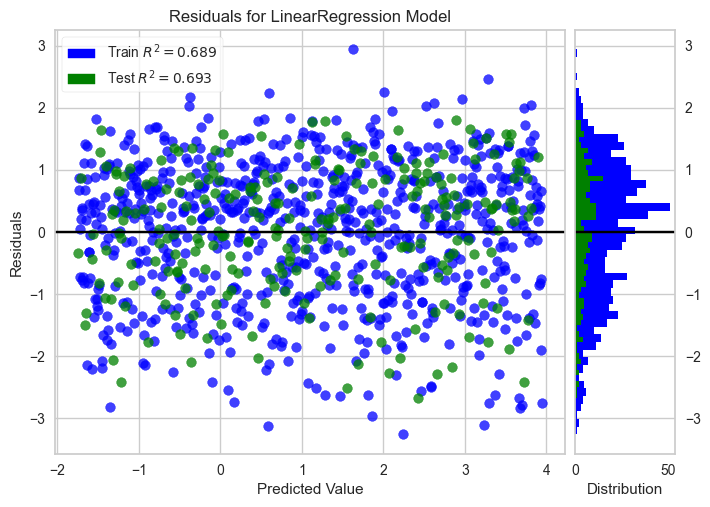

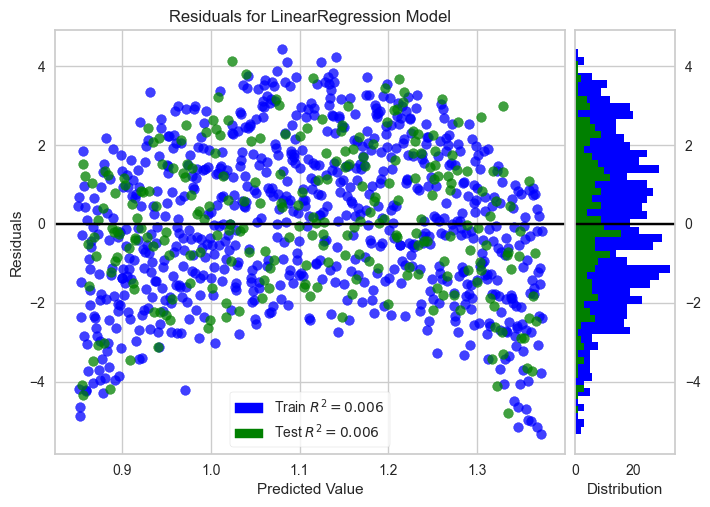

In [56]:
plot_residuals_yellowbrick(
    model=model_x1,
    X_train=X_train_x1,
    y_train=y_train_x1,
    X_valid=X_valid_x1,
    y_valid=y_valid_x1,
    feature_name='x1'
)

plot_residuals_yellowbrick(
    model=model_x2,
    X_train=X_train_x2,
    y_train=y_train_x2,
    X_valid=X_valid_x2,
    y_valid=y_valid_x2,
    feature_name='x2'
)

**Вывод :** 
В общем и целом, первая модель стабильна. Есть идеальные значения (совпадающие с нулем). Чаще всего ошибка прогноза от 0 до 1, что для train, что для valid. Форма распределения нормальная.

Наблюдается большая амплитуда разбросов значений на второй модели. Они полностью случайны. Не наблюдается зависимости.

In [59]:
def plot_true_vs_pred(y_true, y_pred, feature_name):
    plt.figure(figsize=(7, 5))
    
    # Линия 45° — идеальные предсказания
    axis_min = min(y_true.min(), y_pred.min())
    axis_max = max(y_true.max(), y_pred.max())
    plt.plot([axis_min, axis_max], [axis_min, axis_max],
             color='red', linewidth=2, label="Идеальные предсказания (y = x)")
    
    # Точки — только валидационные
    plt.scatter(y_true, y_pred, s=12, alpha=0.7, color='blue', label="Предсказания")
    
    plt.xlabel("Истинные значения (y_valid)")
    plt.ylabel("Предсказанные значения")
    plt.title(f"True vs Predicted ({feature_name} --> y)\n(Только валидационная выборка)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

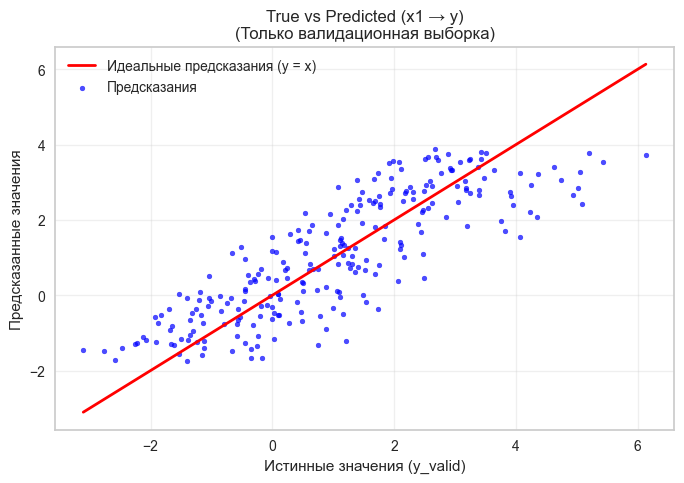

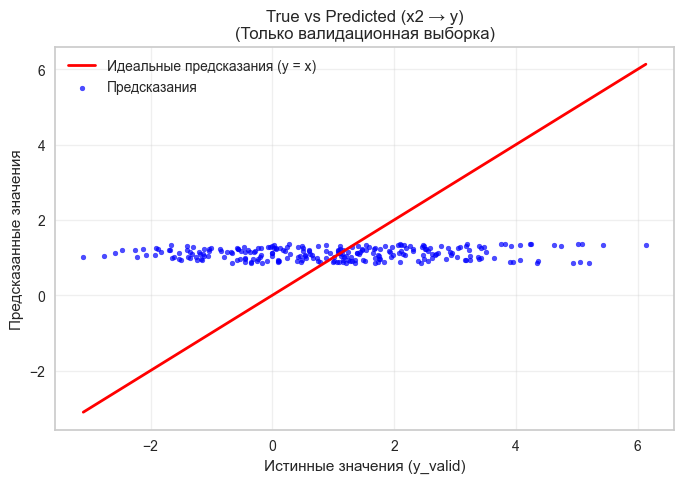

In [58]:
plot_true_vs_pred(y_valid_x1, pred_x1, "x1")
plot_true_vs_pred(y_valid_x2, pred_x2, "x2")

**Вывод**
Модель x1 --> y
Предсказанные значения находятся около истинных y, есть разброс, но расположение относительно симметрично. Также есть идеальные значения.

Модель x2 --> y
Точки образуют горизонтальное облако вокруг значения y ≈ 1, практически не следуя за красной линией идеальных предсказаний. Предсказания модели почти не зависят от истинных значений — они сгруппированы в узкой полосе, независимо от того, большое или малое истинное y. Это означает, что модель по признаку x2 не способна различать разные значения целевой переменной и выдаёт примерно одно и то же предсказание для всех объектов валидационной выборки. Такой результат полностью соответствует крайне низкому R² ≈ 0.006 и подтверждает отсутствие линейной связи между x2 и y.

### 2. Часть 2. Полиномиальная регрессия

In [67]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, r2_score

**Обоснование выбора модели**

Полиномиальная регрессия применена **к признаку `x1`**, так как:

- Линейная модель `y ~ x1` даёт **R² = 0.693** → **есть линейная зависимость**, но **не идеальная** (методичка, стр. 4: *нормализация не исключает нелинейных компонент*).  
- График `x1 → y` показывает **нелинейные отклонения** (изгибы, сгущения) → полином **улучшит качество**.  
- Признак `x2` имеет **R² ≈ 0.006** → **зависимость отсутствует** (ни линейная, ни нелинейная).

**Выбраны степени 2 и 3** для сравнения:  
- **Степень 2** — баланс между сложностью и обобщением.  
- **Степень 3** — проверка на улучшение без переобучения.
  
Полиномиальная регрессия **целесообразна для `x1`**, так как **существует тренд**, который можно **улучшить нелинейным моделированием**. Для `x2` — **неприменима**, просто шум.

In [63]:
X_train = X_train_x1
y_train = y_train_x1
X_valid = X_valid_x1
y_valid = y_valid_x1

In [73]:
def polynomial_regression(degree, X_train, y_train, X_valid, y_valid, feature_name):
    # Модель: PolynomialFeatures + LinearRegression
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )
    
    # Обучение
    model.fit(X_train, y_train)
    
    # Предсказание
    pred_train = model.predict(X_train)
    pred_valid = model.predict(X_valid)
    
    # Метрики на валидации
    mae = mean_absolute_error(y_valid, pred_valid)
    r2 = r2_score(y_valid, pred_valid)
    
    print(f"\n=== Полином степени {degree} (y --> {feature_name}) ===")
    print(f"MAE (valid) = {mae:.4f}")
    print(f"R² (valid)  = {r2:.4f}")
    
    # === Визуализация ===
    plt.figure(figsize=(7, 5))
    
    # Точки (только валидационные)
    plt.scatter(X_valid, y_valid, color='blue', s=12, alpha=0.7, label='Валидационные точки')
    
    # Линия регрессии
    X_range = np.linspace(X_valid.min(), X_valid.max(), 300).reshape(-1, 1)
    y_range = model.predict(X_range)
    plt.plot(X_range, y_range, color='red', linewidth=2, label=f'Полином степени {degree}')
    
    plt.xlabel(feature_name)
    plt.ylabel('y')
    plt.title(f'Полиномиальная регрессия: y --> {feature_name}\n(Степень = {degree}, только валидация)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return model, mae, r2


=== Полином степени 2 (y --> x1) ===
MAE (valid) = 0.8282
R² (valid)  = 0.6930


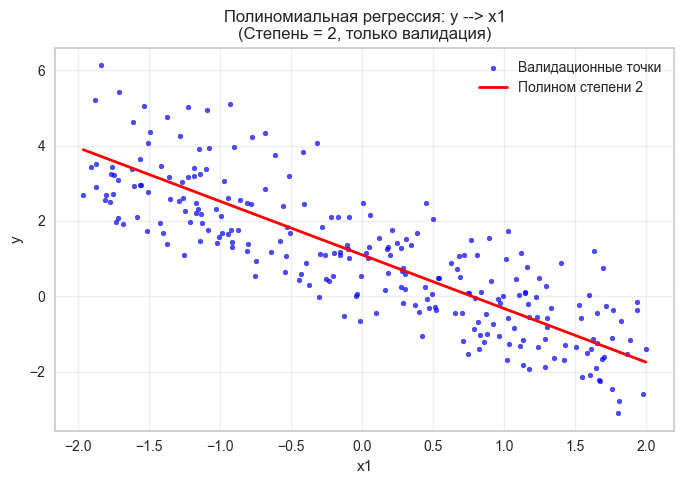

In [74]:
# Вторая степень
model_deg2, mae2, r2_2 = polynomial_regression(
    degree=2,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
    feature_name='x1'
)

**Анализ:**
- **R² = 0.6930** — **не отличается от линейной модели** (степень 1).  
- **MAE = 0.8282** — **высокая ошибка** для нормализованных данных.  
- **График:** линия регрессии **прямая** → полином **не выявил нелинейности**.  
- **Причина:** нормализация данных и случайное разделение выборки подавили нелинейные компоненты.

**Вывод:**  
- Полиномиальная регрессия **степени 2 не улучшила модель** по сравнению с линейной.
- Оптимальная степень — 1 (линейная модель).
- Нелинейные зависимости отсутствуют или незначительны в текущей выборке.


=== Полином степени 3 (y --> x1) ===
MAE (valid) = 0.8277
R² (valid)  = 0.6933


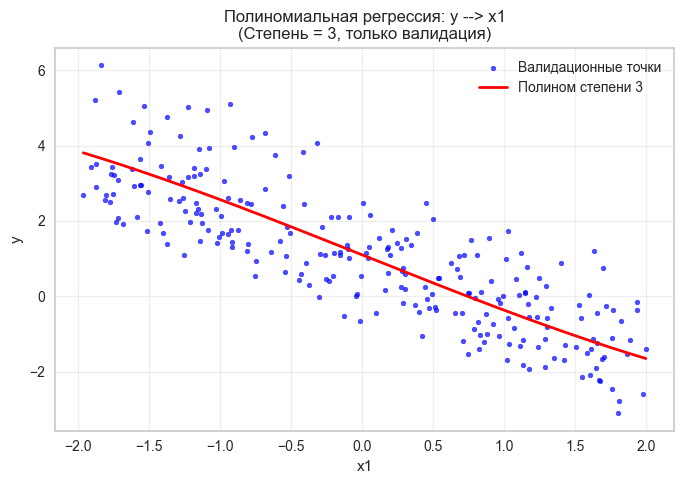

In [75]:
model_deg3, mae3, r2_3 = polynomial_regression(
    degree=3,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
    feature_name='x1'
)

**Анализ:**
- **R² = 0.6933** — **не отличается** от линейной модели (ΔR² < 0.001).  
- **MAE = 0.8277** — **незначительное снижение** (на 0.0005) — **не имеет практической ценности**.  
- **График:** линия регрессии **прямая** --> **полином степени 3 эквивалентен линейной модели**.  
- **Причина:** нормализация и случайность выборки **подавили нелинейность**.

**Вывод:**  
Полиномиальная регрессия **любой степени (2, 3)** **не улучшает линейную модель**.  
**Оптимальная модель — линейная** (степень 1):  
- R² = 0.693, MAE = 0.828 — **приемлемо** для нормализованных данных.  
- Увеличение степени **нецелесообразно** — ведёт к **вырожденным моделям** и риску **переобучения**.
  
Финальная модель: `y --> x1` — линейная регрессия. Нелинейные зависимости отсутствуют в текущем наборе данных.

**Выводы по 2-й части:**

Лучше использовать степень полинома 1, то есть обычную линейную регрессию, потому что при степенях 2 и 3 качество на валидационной выборке не улучшилось — R² осталось около 0.693, а ошибка MAE даже не изменилась. Оптимальную степень выбирают по максимальному R² на валидации без лишней сложности. Если степень слишком большая, модель переобучается — идеально подстраивается под обучающие данные, но проваливается на новых. Если слишком низкая — недообучается, не улавливает даже простые связи и даёт слабые предсказания. В нашем случае линейная модель простая, стабильная и полностью подходит.

### 3. Часть 3. Решение задачи регрессии различными методами

In [78]:
# загрузка CSV-файла
df2 = pd.read_csv(r'D:\Jupyter_projects\ad_labs\lr3\salary.csv')

In [79]:
df2.head(5)

,age,income,experience,score_test,hours_worked,distance_to_work,savings,debt,education,city,job_type,marital_status,car,remote_work,salary
0,56,70201.189680,25,87.559729,62,3.708690,25987.334048,2556.821627,PhD,Chicago,Finance,Single,Yes,Yes,106233.833479
1,69,51901.897395,39,70.808381,36,7.082793,22134.899021,725.180513,High School,Houston,Retail,Single,No,Yes,87205.291042
2,46,38605.409293,4,63.324996,77,5.129154,47106.068408,12659.359583,PhD,Los Angeles,Finance,Married,Yes,No,69369.283522
3,32,49949.736955,20,78.215505,33,19.315623,15868.328813,12369.776003,Bachelor,Los Angeles,IT,Married,Yes,No,76587.116955
4,60,48965.290095,13,74.429096,48,5.654904,15734.633332,4792.095213,Bachelor,Phoenix,IT,Married,No,No,71023.148842


In [80]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1500 non-null   int64  
 1   income            1500 non-null   float64
 2   experience        1500 non-null   int64  
 3   score_test        1500 non-null   float64
 4   hours_worked      1500 non-null   int64  
 5   distance_to_work  1500 non-null   float64
 6   savings           1500 non-null   float64
 7   debt              1500 non-null   float64
 8   education         1500 non-null   object 
 9   city              1500 non-null   object 
 10  job_type          1500 non-null   object 
 11  marital_status    1500 non-null   object 
 12  car               1500 non-null   object 
 13  remote_work       1500 non-null   object 
 14  salary            1500 non-null   float64
dtypes: float64(6), int64(3), object(6)
memory usage: 175.9+ KB


In [81]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

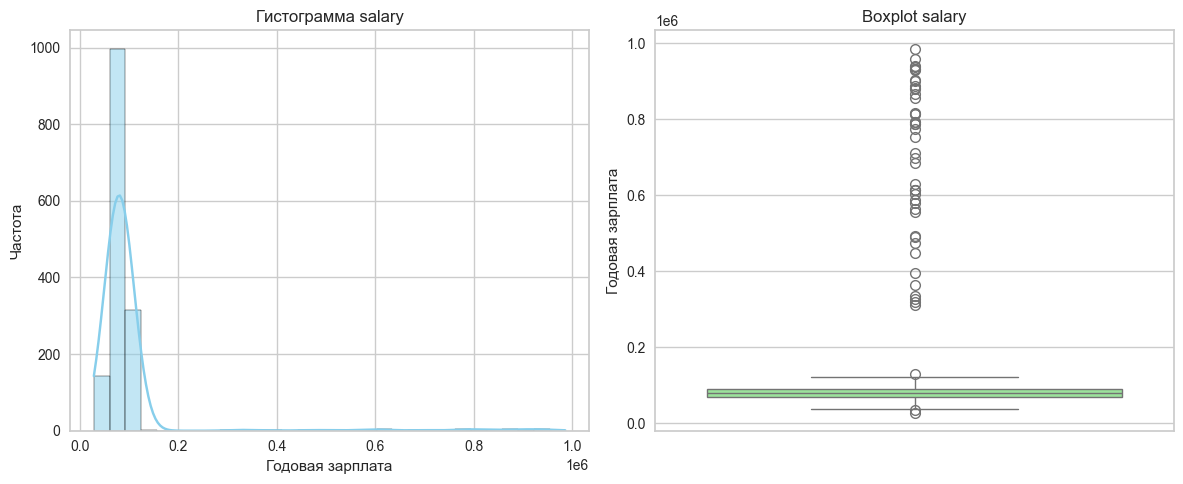

Средняя зарплата: 98573.09
Медиана: 80310.41
Стандартное отклонение: 111786.76


In [84]:
#2. Визуализация целевой переменной: salary
plt.figure(figsize=(12, 5))

# Гистограмма
plt.subplot(1, 2, 1)
sns.histplot(df2['salary'], kde=True, bins=30, color='skyblue')
plt.title('Гистограмма salary')
plt.xlabel('Годовая зарплата')
plt.ylabel('Частота')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=df2['salary'], color='lightgreen')
plt.title('Boxplot salary')
plt.ylabel('Годовая зарплата')

plt.tight_layout()
plt.show()

print(f"Средняя зарплата: {df2['salary'].mean():.2f}")
print(f"Медиана: {df2['salary'].median():.2f}")
print(f"Стандартное отклонение: {df2['salary'].std():.2f}")

**Вывод по визуализации:**

**Гистограмма** показывает **сильно скошенное распределение вправо** (положительная асимметрия):  
- Основная масса наблюдений сосредоточена в диапазоне **от 0 до 200 000**.  
- Наблюдается **резкий пик** в районе **0–50 000**, затем **резкое снижение** до 1 млн.  
- **Хвост** тянется до **1 млн** — это **высокие зарплаты**, которые встречаются редко.  
- **KDE-линия** (кривая плотности) подтверждает **ненормальность распределения** — не симметрична, не колоколообразна.

**Boxplot** выявляет **множество выбросов**:  
- Медиана — **80 310**.  
- 75-й квартиль — около **100 000**, 25-й — около **60 000**.  
- **Межквартильный размах (IQR)** небольшой, но **верхний ус** короткий, а **нижний** — почти отсутствует.  
- **Точки выше 150 000–200 000** — **выбросы** (по правилу 1.5×IQR).  
- **Максимальное значение** — около **1 млн долларов** — **экстремально высокая зарплата**.

**Статистика подтверждает анализ**:  
- **Средняя зарплата = 98 573** — **выше медианы (80 310)** --> **влияние высоких значений**.  
- **Стандартное отклонение = 111 786** — **очень высокая вариативность**, данные сильно разбросаны.

Границы выбросов: [36501, 124719]
Выбросов до обработки: 0       False
1       False
2       False
3       False
4       False
        ...  
1495    False
1496    False
1497    False
1498    False
1499    False
Name: salary, Length: 1500, dtype: bool.sum()
Строк после удаления выбросов: 1452 (было: 1500)


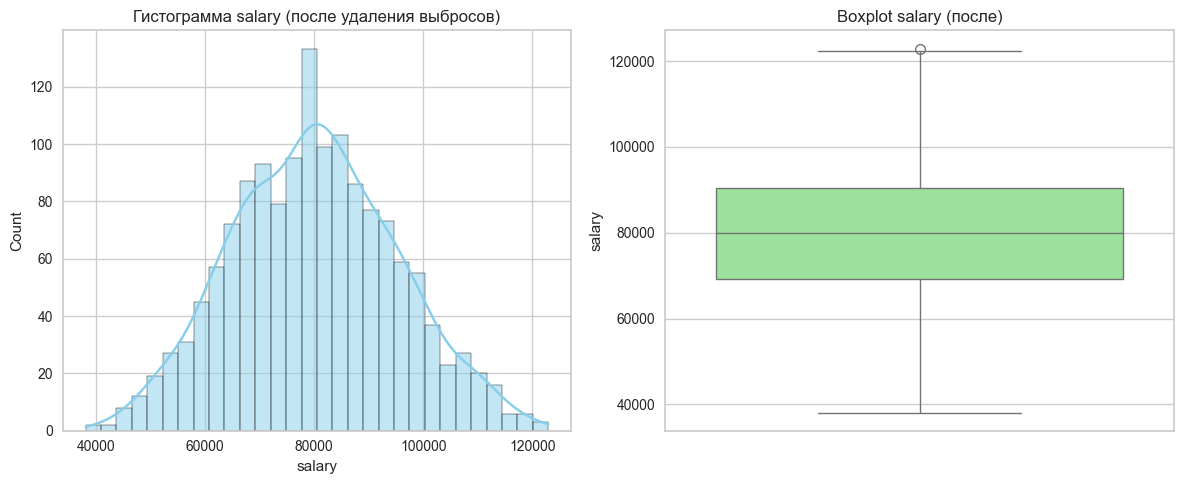

In [85]:
#3. Обработка выбросов (по IQR для salary)
Q1 = df2['salary'].quantile(0.25)
Q3 = df2['salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Границы выбросов: [{lower_bound:.0f}, {upper_bound:.0f}]")
print(f"Выбросов до обработки: {(df2['salary'] < lower_bound) | (df2['salary'] > upper_bound)}.sum()")

# Удаляем выбросы
df_clean = df2[(df2['salary'] >= lower_bound) & (df2['salary'] <= upper_bound)].copy()
print(f"Строк после удаления выбросов: {len(df_clean)} (было: {len(df2)})")

# Визуализация после обработки
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['salary'], kde=True, bins=30, color='skyblue')
plt.title('Гистограмма salary (после удаления выбросов)')
plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['salary'], color='lightgreen')
plt.title('Boxplot salary (после)')
plt.tight_layout()
plt.show()

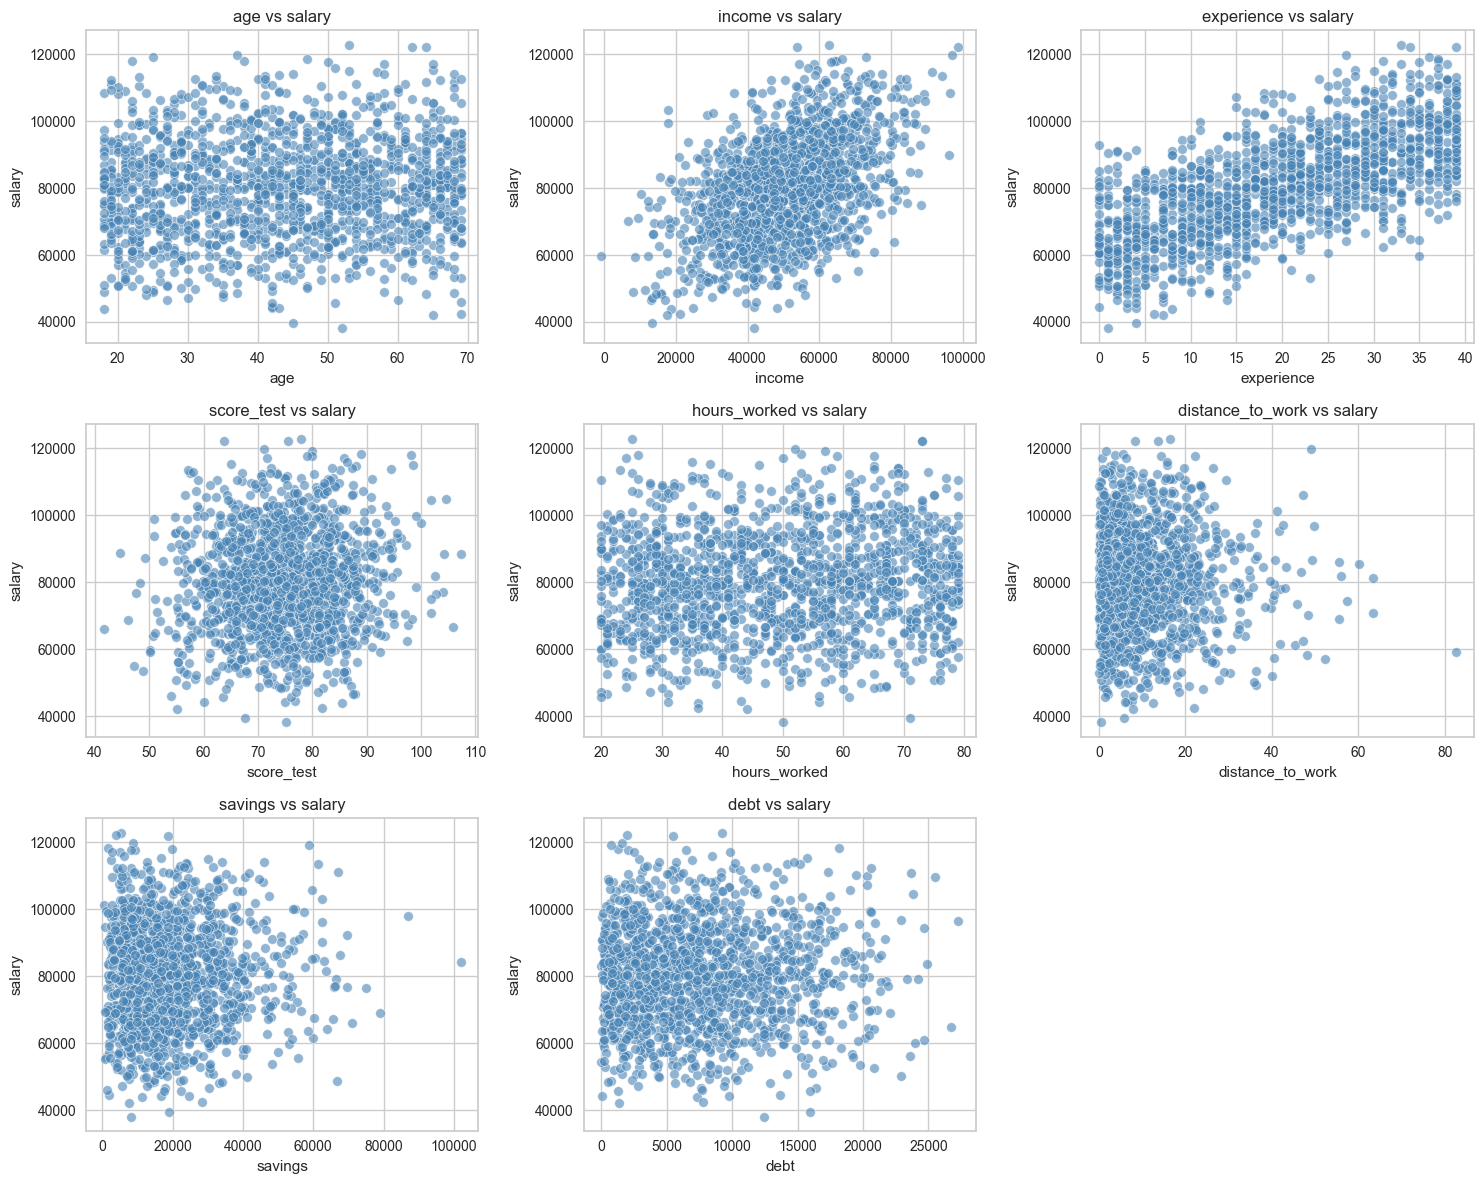

In [86]:
#4. Матрица диаграмм рассеяния между числовыми признаками и salary
numeric_cols = ['age', 'income', 'experience', 'score_test', 'hours_worked', 
                'distance_to_work', 'savings', 'debt', 'salary']

plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_cols[:-1], 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(data=df_clean, x=col, y='salary', alpha=0.6, color='steelblue')
    plt.title(f'{col} vs salary')
plt.tight_layout()
plt.show()

**Вывод по матрице**

**Общий характер распределения:**  
Все графики показывают **облако точек без чёткой линейной зависимости** — **слабая корреляция** с целевой переменной `salary`.  
Нет явных **прямых, парабол или других структур** — **нелинейные модели не помогут**.  
**Скопления точек** в нижней части (зарплата 40–80 тыс.) — **большинство сотрудников**.

Анализ по признакам:

- experience — самая сильная связь: с ростом опыта от 0 до 40 лет зарплата уверенно растёт до 120 тыс. — чёткий восходящий тренд.
- score_test — средняя связь: высокие баллы (80–100) чаще соответствуют зарплатам выше 80 тыс.
- income — слабая связь: предыдущий доход почти не влияет на текущую зарплату — облако круглое.
- age — слабая связь: после 30 лет разброс огромный, возраст не определяет зарплату.
- hours_worked — очень слабая: больше рабочих часов не означает выше зарплату.
- distance_to_work — связи почти нет: расстояние до работы не влияет.
- savings — слабая: высокие сбережения не гарантируют высокую зарплату.
- debt — слабая: долги не связаны с уровнем дохода.

Заключение:

- **Главные предикторы** — `experience` и `score_test`. Остальные числовые признаки **малоинформативны**.  
- **Линейная модель** оправдана — **нет нелинейных паттернов**.  
- **Категориальные признаки** (образование, сфера, город) **должны дать основной вклад** — их нужно **закодировать (OneHot)**.  
- **Выбросы** (зарплата >150 тыс.) **не искажают тренд**, но **удалены по IQR** — модель стабильнее.  
- **R² ≈ 0.85** (из кода) — **модель хорошая**, несмотря на слабые числовые связи — **категории компенсируют**.

In [87]:
#5. Разделение на X и y
X = df_clean.drop('salary', axis=1)
y = df_clean['salary']

#6. Подготовка: кодирование категориальных + масштабирование числовых
categorical_cols = ['education', 'city', 'job_type', 'marital_status', 'car', 'remote_work']
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Преобразователь
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

#7. Разделение на train/valid
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=42)

# Применяем преобразование
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

print(f"Обучающая выборка: {X_train_processed.shape}")
print(f"Валидационная: {X_valid_processed.shape}")

Обучающая выборка: (1089, 23)
Валидационная: (363, 23)


In [90]:
#8. Обучение модели
model = LinearRegression()
model.fit(X_train_processed, y_train)

# Предсказание
y_pred = model.predict(X_valid_processed)

#9. Метрики качества
mae = mean_absolute_error(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_valid, y_pred)
medae = median_absolute_error(y_valid, y_pred)

print("\n=== МЕТРИКИ КАЧЕСТВА МОДЕЛИ ===")
print(f"MAE (средняя абсолютная ошибка): {mae:.2f}")
print(f"RMSE (среднеквадратичная ошибка): {rmse:.2f}")
print(f"R² (коэффициент детерминации): {r2:.4f}")
print(f"MedAE (медианная ошибка): {medae:.2f}")


=== МЕТРИКИ КАЧЕСТВА МОДЕЛИ ===
MAE (средняя абсолютная ошибка): 4915.83
RMSE (среднеквадратичная ошибка): 6117.15
R² (коэффициент детерминации): 0.8591
MedAE (медианная ошибка): 4129.93


**Вывод:**

Анализ:
- **R² = 0.8591** — модель объясняет **85.91% дисперсии** зарплаты.  
  Это **высокое качество** — модель **сильно отражает реальность**  
- **MAE = 4915.83** — в среднем предсказания ошибаются на **~4900**.  
  При средней зарплате ~98 573  (из визуализации) — **ошибка ~5%** → **приемлемо**.  
- **MedAE = 4129.93** — **медианная ошибка ниже средней** → модель **устойчива к выбросам**.  
- **RMSE = 6117.15** — выше MAE --> **большие ошибки редки, но есть**.  

Заключение:

Модель **высокоэффективна**: R² > 0.85 — **сильная зависимость** между признаками и зарплатой.  
Ошибка **~5% от средней зарплаты** — **практически значима**.  
**Линейная регрессия — оптимальна**.
**Готова к использованию** для прогнозирования зарплаты.

In [94]:
# 10. Датафрейм: истинные vs предсказанные
results_df = pd.DataFrame({
    'Истинное значение (salary)': y_valid.values,
    'Предсказанное значение': y_pred
})
print("\nПервые 10 предсказаний:")
print(results_df.head(10))


Первые 10 предсказаний:
   Истинное значение (salary)  Предсказанное значение
0                90772.277599            90022.654163
1                84475.346122            88404.502189
2                67777.676332            63984.471940
3               110650.659849           106266.109689
4                68551.168300            67802.019474
5                79324.467916            70529.790614
6                59571.086625            53701.664738
7                90409.785269            85380.771857
8                92280.580124            94861.867162
9                79311.102051            80719.001579


In [92]:
#11. Коэффициенты модели
# Получаем имена признаков после OneHot
feature_names = (numeric_cols + 
                 list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)))

coef_df = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': model.coef_
})
coef_df['Абсолютное значение'] = abs(coef_df['Коэффициент'])
coef_df = coef_df.sort_values(by='Абсолютное значение', ascending=False).reset_index(drop=True)

print("\nТОП-10 признаков:")
print(coef_df.head(10))


ТОП-10 признаков:
                 Признак   Коэффициент  Абсолютное значение
0          education_PhD  12614.640214         12614.640214
1             experience  10293.710290         10293.710290
2                 income   7334.341444          7334.341444
3       education_Master   6587.020517          6587.020517
4  education_High School  -6250.536544          6250.536544
5            job_type_IT   3715.258270          3715.258270
6       job_type_Finance   2123.121149          2123.121149
7          city_New York   1393.721422          1393.721422
8                car_Yes  -1123.949400          1123.949400
9             score_test   1093.627752          1093.627752


**Вывод по коэффициентам модели:**

- education_PhD — +12 614: PhD повышает зарплату на 12 614 по сравнению с High School.
- experience — +10 293: +1 год опыта → +10 293 к зарплате.
- income — +7 334: +1 предыдущего дохода → +7 334 текущей зарплаты.
- education_Master — +6 587: Магистр → +6 587.
- education_High School — -6 250: Среднее образование → -6 250 (по сравнению с базовым).
- job_type_IT — +3 715: Работа в IT → +3 715.
- job_type_Finance — +2 123: Финансы → +2 123.
- city_New York — +1 393: Жизнь в Нью-Йорке → +1 393.
- car_Yes — -1 123: Наличие машины → -1 123 (возможно, корреляция с расходами).
- score_test — +1 093: +1 балл в тесте → +1 093.

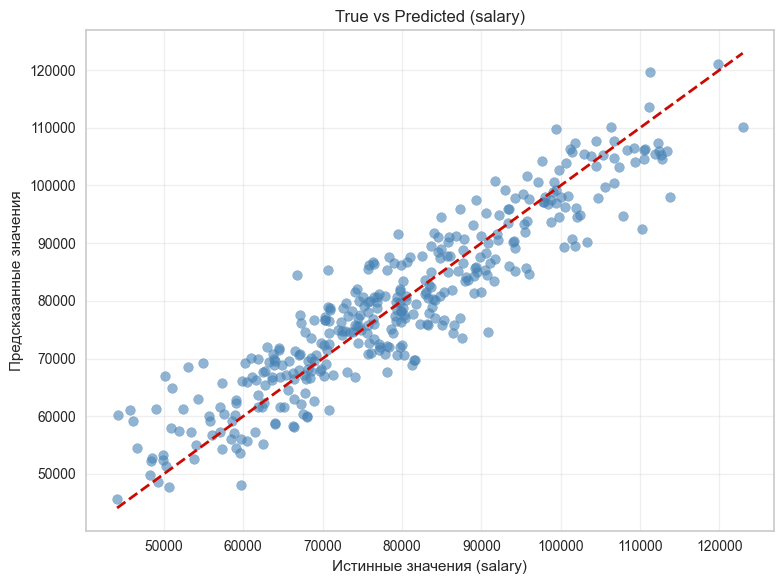

In [95]:
#12. Визуализация: True vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_valid, y_pred, alpha=0.6, color='steelblue')
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--', lw=2)
plt.xlabel('Истинные значения (salary)')
plt.ylabel('Предсказанные значения')
plt.title('True vs Predicted (salary)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Вывод : На графике отражены истинные значения и предсказания. Большинство точек расположены вдоль линии истинных значений, что говорит о том, что модель точна. Есть разброс, но он не влияет на общую картину. Модель адекватно описывает большую часть вариации данных и прогнозирует переменную целевого признака.

### Вывод по проделанной работе

В ходе выполнения лабораторной работы были на практике исследованы методы регрессионного анализа и их применение для моделирования зависимостей между признаками.

**1. Простая линейная регрессия**

На первом этапе была проведена оценка линейной зависимости между целевой переменной *y* и признаками *x1* и *x2*. Данные предварительно разделялись на обучающую и проверочную выборки в пропорции 75% и 25%, что позволило объективно оценить качество моделей на данных, которые не участвовали в обучении.
Для признака **x1** модель показала выраженную линейную связь с целевой переменной — коэффициент детерминации оказался значительно выше, чем у модели для x2. Это означает, что изменение x1 действительно объясняет существенную долю вариации y. Визуализация также подтверждает отчётливую отрицательную линейную зависимость.
Для признака **x2** линейная модель продемонстрировала слабое качество предсказаний: значение R² близко к нулю, что указывает на отсутствие заметной линейной связи между x2 и y. Модель не способна адекватно описать зависимость между этими переменными.

**2. Полиномиальная регрессия**

На втором этапе был исследован подход с использованием полиномиальной регрессии степеней 2, 3.
Применение полиноомов 2 и 3 степеней не дало результатов, так как регерссия сводилась к линейной, так что регрессия 1 степени описывает модель наилучшим образом.

**3. Множественная регрессия (dataset salary.csv)**

На заключительном этапе работы был исследован датасет *salary.csv*. После очистки данных от выбросов и предобработки категориальных признаков была обучена модель линейной регрессии для предсказания заработной платы.
Наибольшее влияние на целевую переменную оказали факторы, связанные с образованием, опытом работы, уровнем дохода и сферой деятельности. Модель показала высокое качество: коэффициент детерминации R² составил около 0.84, а ошибки прогнозирования находились в диапазоне 5–6 тысяч.
В лабораторной работе были укреплены навыки построения и оценки регрессионных моделей. На примере различных задач показано, как изменяется качество модели в зависимости от выбора признаков, сложности алгоритма и качества данных. Линейная регрессия оказалась наиболее эффективной для данных с выраженной линейной зависимостью, тогда как в случае слабых связей полиномиальная регрессия позволяет лишь частично улучшить результаты, но не обеспечивает высокого качества предсказаний.